# Pipeline EHBG-FACS · 01 · Métodos Exactos (Branch & Cut)

**Paradigma 1 — cota de costo óptimo determinista con Gurobi.**

Resuelve el CVRP sobre el **tiempo de viaje nominal** con formulación de flujo no dirigida y branch-and-cut (cortes RCI/DFJ como *lazy constraints*). Las ventanas y retrasos entran como **recurso de 2ª etapa** en la evaluación. Garantiza el óptimo en instancias pequeñas; su intratabilidad aparece al crecer *n*.

In [1]:
# === Configuración del entorno (ejecuta esta celda primero) =================
# Requiere: (a) el paquete `svrplab` (carpeta experiments/colab del repo de tesis)
#           (b) el repo oficial de SVRPBench (se clona solo en bootstrap.init()).
REPO_URL  = "https://github.com/AbrahamHub/TESIS-ANT"   # <-- EDITA si tu repo difiere
USE_DRIVE = True   # persistir banco/resultados/modelos en Google Drive (recomendado)

import os, sys, subprocess

if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print("Drive no disponible (¿ejecutas local?):", e)

def _find_svrplab():
    cands = ["/content/drive/MyDrive/TESIS-ANT/experiments/colab",
             "/content/TESIS-ANT/experiments/colab",
             os.path.join(os.getcwd(), "experiments", "colab"),
             os.getcwd()]
    for c in cands:
        if os.path.isdir(os.path.join(c, "svrplab")):
            return c
    return None

_path = _find_svrplab()
if _path is None:
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, "/content/TESIS-ANT"], check=False)
    _path = "/content/TESIS-ANT/experiments/colab"
sys.path.insert(0, _path)
print("svrplab en:", _path)

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy", "scipy", "pandas",
                "matplotlib", "scikit-learn", "pillow", "tqdm"], check=False)
# torch ya viene en Colab. gurobipy solo se instala en el notebook del paradigma 1.

from svrplab import bootstrap, protocol, data, runner, metrics, viz
env   = bootstrap.init()        # GPU + repo oficial SVRPBench + rutas (Drive si está montado)
proto = protocol.DEFAULT
print("device:", env.device, "| raíz de artefactos:", env.paths.root)

Mounted at /content/drive
svrplab en: /content/TESIS-ANT/experiments/colab
[bootstrap] repo oficial ya presente en /content/drive/MyDrive/EHBG_FACS/svrpbench
[bootstrap] GPU detectada: Tesla T4 (14.6 GB) | torch 2.11.0+cu128 CUDA 12.8
[bootstrap] raíz de artefactos: /content/drive/MyDrive/EHBG_FACS
[bootstrap] results/ figures/ data/ listos | seed=12345 device=cuda
device: cuda | raíz de artefactos: /content/drive/MyDrive/EHBG_FACS


## Gurobi
`gurobipy` trae una licencia **restringida** (≤2000 variables): la formulación no dirigida cabe para n≤50 (n=50 → 1275 aristas). Para n>~63 usa la **licencia académica gratuita** (`grbgetkey`).

In [2]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gurobipy"], check=False)
import gurobipy; print("Gurobi", gurobipy.gurobi.version())

Gurobi (13, 0, 2)


In [3]:
# === Configuración del experimento (IDÉNTICA en los 5 notebooks) ============
# Para garantizar el "piso parejo", TODOS los notebooks deben usar los MISMOS
# SIZES y N_INSTANCES: así resuelven exactamente el mismo banco de instancias.
SIZES       = [10, 20, 50]           # clientes. Extiende a [50,100,200,300] (ver notas).
N_INSTANCES = proto.instances_per_size   # 30 (rigor estadístico). Corrida rápida: pon 5.

bank = data.load_bank(env.paths.instances, SIZES, N_INSTANCES,
                      base_seed=proto.base_seed, capacity_mode=proto.capacity_mode, verbose=True)
print({s: len(v) for s, v in bank.items()}, "instancias por tamaño")

OR-Tools not available: No module named 'ortools'
[data] n=10: 30 instancias (cache) -> bank_n10_m30_s12345_binding.npz
[data] n=20: 30 instancias (cache) -> bank_n20_m30_s12345_binding.npz
[data] n=50: 30 instancias (cache) -> bank_n50_m30_s12345_binding.npz
{10: 30, 20: 30, 50: 30} instancias por tamaño


## Resolver
El solver valida cada solución post-resolución (capacidad, cobertura, gap≥0). Si una instancia excede la licencia de Gurobi, redúcela o usa licencia académica.

In [4]:
from svrplab.solvers.exact_bc import ExactBranchCut
solver = ExactBranchCut(time_limit=120.0, verbose=False)
df = runner.run_solver(solver, "exact-bc", bank, env, proto, verbose=True)
df

Restricted license - for non-production use only - expires 2027-11-29
  [exact-bc] n=10 inst=0: E[c]=1840.4 E[c+Q]=2104.2 CVaR=2104.6 feas=0.00 veh=3 t=0.004s (wall 0.1s)
  [exact-bc] n=10 inst=1: E[c]=2198.5 E[c+Q]=4077.4 CVaR=4078.0 feas=0.00 veh=3 t=0.005s (wall 0.1s)
  [exact-bc] n=10 inst=2: E[c]=2618.5 E[c+Q]=3100.4 CVaR=3100.9 feas=0.00 veh=3 t=0.038s (wall 0.2s)
  [exact-bc] n=10 inst=3: E[c]=2297.6 E[c+Q]=3671.9 CVaR=3672.5 feas=0.00 veh=3 t=0.045s (wall 0.2s)
  [exact-bc] n=10 inst=4: E[c]=1912.4 E[c+Q]=2575.1 CVaR=2575.4 feas=0.00 veh=3 t=0.020s (wall 0.1s)
  [exact-bc] n=10 inst=5: E[c]=1965.5 E[c+Q]=2369.9 CVaR=2370.3 feas=0.00 veh=3 t=0.074s (wall 0.2s)
  [exact-bc] n=10 inst=6: E[c]=2437.5 E[c+Q]=3683.5 CVaR=3684.0 feas=0.00 veh=2 t=0.063s (wall 0.2s)
  [exact-bc] n=10 inst=7: E[c]=2576.6 E[c+Q]=2897.7 CVaR=2898.0 feas=0.00 veh=3 t=0.013s (wall 0.1s)
  [exact-bc] n=10 inst=8: E[c]=2413.4 E[c+Q]=4083.4 CVaR=4083.8 feas=0.00 veh=3 t=0.005s (wall 0.1s)
  [exact-bc] n=10 ins

,solver,paradigm,size,instance,seed,det_cost,expected_cost,expected_total,cvar,feasibility,cvr,robustness,tw_violations,runtime,train_time_s,gap,n_vehicles
0,exact-bc,1,10,0,22345,1840.377290,1840.423955,2104.224644,2104.554282,0.0,20.00,0.123992,2.000,0.003902,NaN,0.000000,3
1,exact-bc,1,10,1,22346,2198.382326,2198.454434,4077.441369,4077.975849,0.0,60.00,0.123842,6.000,0.005471,NaN,0.000000,3
2,exact-bc,1,10,2,22347,2618.392815,2618.459042,3100.369100,3100.893069,0.0,30.00,0.134502,3.000,0.038470,NaN,0.000000,3
3,exact-bc,1,10,3,22348,2297.532054,2297.605131,3671.887617,3672.460969,0.0,60.00,0.137592,6.000,0.045066,NaN,0.000000,3
4,exact-bc,1,10,4,22349,1912.364371,1912.407075,2575.087787,2575.363098,0.0,20.00,0.115905,2.000,0.020273,NaN,0.000000,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,exact-bc,1,50,25,62370,19519.115029,19519.654371,20960.200614,20961.071534,0.0,8.00,0.381479,4.000,120.053739,NaN,0.740862,44
86,exact-bc,1,50,26,62371,22499.633110,22500.097436,25021.089449,25021.962773,0.0,12.00,0.354081,6.000,120.001487,NaN,0.734062,37
87,exact-bc,1,50,27,62372,10907.840777,10908.133722,16372.543304,16373.598062,0.0,30.00,0.292621,15.000,120.003350,NaN,0.351348,14
88,exact-bc,1,50,28,62373,6173.562011,6174.141471,12270.229543,12272.942655,0.0,35.99,4.044435,17.995,120.000936,NaN,0.176733,10


## Métricas agregadas y figuras

,solver,size,det_cost,expected_cost,expected_total,cvar,feasibility,cvr,robustness,tw_violations,runtime,train_time_s,gap,n_vehicles,expected_cost_std,expected_total_std,cvar_std
0,exact-bc,10,2311.491426,2311.583395,3474.962737,3475.890208,0.0,33.333333,0.515816,3.333333,0.031323,NaN,0.000000,2.900000,339.636148,600.928547,601.120881
1,exact-bc,20,3698.695234,3698.829353,6447.925723,6449.113210,0.0,37.000000,0.419762,7.400000,0.310826,NaN,0.000000,3.933333,515.555026,913.563328,914.274057
2,exact-bc,50,17103.942744,17104.533730,20914.693932,20918.840597,0.0,22.132333,2.337503,11.066167,120.012823,NaN,0.608292,29.300000,4941.579656,3869.830918,3869.692241


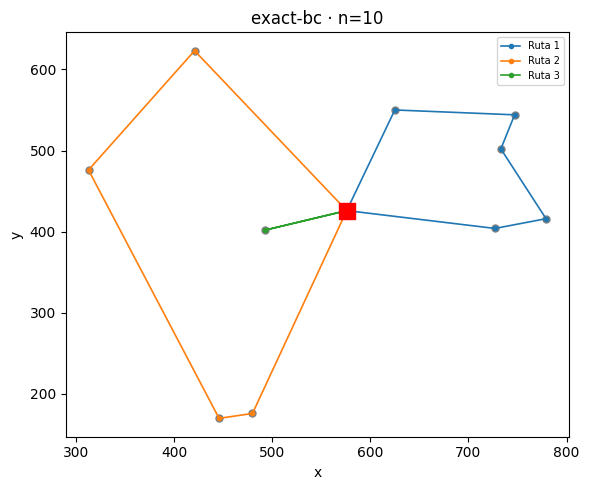

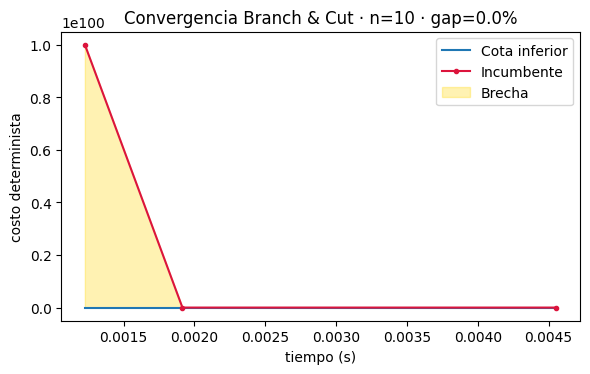

In [5]:
agg = metrics.aggregate_by_size(df); display(agg)
import matplotlib.pyplot as plt
# Ruta + convergencia B&C de la primera instancia del menor tamaño
inst = bank[SIZES[0]][0]
sol = solver.solve(inst, num_realizations=proto.realizations)
viz.plot_routes(inst, sol.routes, title=f"exact-bc · n={SIZES[0]}"); plt.show()
viz.plot_convergence(sol.extras.get("convergence_log", []), gap=sol.extras.get("gap"),
                     n=SIZES[0]); plt.show()

**Interpretación.** `exact-bc` minimiza el costo de viaje nominal e ignora las ventanas en el MIP, por lo que suele lograr el menor `E[c]` pero con factibilidad baja bajo la estocasticidad (las ventanas se violan). Es la referencia de costo, no de robustez.